# 03 - From a Gaussian denoiser to a class-minus-full correction

Notebook `02` showed that a velocity model can also be read as a denoiser. We
now ask whether a much simpler denoiser, built only from a distribution's mean
and principal directions, can recover useful structure. We first test that
question on held-out MNIST images. We then compare a target-class denoiser with
a full-data denoiser at the same 2D state. Their difference,

$$\Delta D = D_{\text{target}} - D_{\text{full}},$$

is a coarse distribution-level correction, not a vector toward a selected
sample.

**Time convention:** `t=0` is noise and `t=1` is data.


In [1]:
import sys
from pathlib import Path

NOTES_DIR = Path.cwd()
if not (NOTES_DIR / "toy_notes.py").exists():
    NOTES_DIR = Path("notebooks/toy_data")
sys.path.insert(0, str(NOTES_DIR.resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from toy_notes import *
from notebook_views import *

SEED = 2026
set_seed(SEED)
device = choose_device()
print("device:", device)


device: cuda


In [2]:
model, losses, _ = load_or_train_model(device=device)
model.eval()
model.requires_grad_(False)

set_seed(SEED + 301)
steering_data, steering_labels = sample_labeled_mixture(30000, device=device)
steering_stats = estimate_gaussian_stats(steering_data, steering_labels)
set_seed(SEED + 302)
evaluation_data, evaluation_labels = sample_labeled_mixture(30000, device=device)
evaluation_stats = estimate_gaussian_stats(evaluation_data, evaluation_labels)
TARGET_CLASS = 2
set_seed(SEED + 303)
target_reference = sample_class(1800, TARGET_CLASS, device=device)
print("target class:", CLASS_NAMES[TARGET_CLASS])


target class: top


## 1. A denoiser built from means and principal directions

A Gaussian model records a mean and covariance. In PCA coordinates, the
covariance tells us which directions vary strongly across clean examples. A
Gaussian posterior mean preserves evidence along those high-variance
directions and shrinks uncertain low-variance directions toward the mean.

The next two functions implement the same rule once with a full covariance
matrix and once in a low-rank PCA basis. The image result comes first; the
formula that explains it follows immediately afterward.


In [3]:
def gaussian_posterior_mean(y, sigma, mean, covariance):
    """E[x_clean | y] when x_clean is Gaussian and y = x_clean + noise."""
    sigma = torch.as_tensor(sigma, device=y.device).reshape(-1)
    if sigma.numel() == 1:
        sigma = sigma.expand(y.shape[0])
    identity = torch.eye(y.shape[1], device=y.device).expand(y.shape[0], -1, -1)
    covariance = covariance.expand(y.shape[0], -1, -1)
    system = covariance + sigma[:, None, None].square() * identity
    solved = torch.linalg.solve(system, (y - mean).unsqueeze(-1))
    return mean + (covariance @ solved).squeeze(-1)

def pca_posterior_mean(y, sigma, stats):
    centered = y - stats.mean
    coordinates = centered @ stats.components
    sigma_squared = torch.as_tensor(sigma, device=y.device).reshape(-1, 1).square()
    variances = stats.variances[None, :]
    shrinkage = variances / (variances + sigma_squared)
    return stats.mean + (coordinates * shrinkage) @ stats.components.T


## 2. Can this simple model recover a noisy digit?

MNIST makes all 784 pixel coordinates visible without needing a large network.
We fit low-rank Gaussian models on the training split only: one to all digits
and one to digit 3. The leading covariance directions are `eigendigits`.
On held-out test images, we first check that the full-data model reduces error
across all ten digits. We then compare both posterior-mean denoisers on digit 3.

**Before you run:** The all-digit model has more training images, while the
digit-3 model has a more specific prior. Which should better recover a held-out
3 at this noise level? Which is more likely to erase unusual handwriting?


In [4]:
MNIST_TARGET = 3
MNIST_RANK = 64
MNIST_SIGMA = 0.45

mnist_train_images, mnist_train_labels = load_mnist_split(train=True, device=device)
mnist_test_images, mnist_test_labels = load_mnist_split(train=False, device=device)

full_fit_indexes = torch.linspace(
    0, mnist_train_images.shape[0] - 1, 12000, device=device
).round().long()
class_fit_pool = torch.where(mnist_train_labels == MNIST_TARGET)[0]
class_fit_indexes = class_fit_pool[: min(6000, class_fit_pool.numel())]

set_seed(SEED + 330)
mnist_full_gaussian = fit_low_rank_gaussian(
    mnist_train_images[full_fit_indexes], rank=MNIST_RANK
)
set_seed(SEED + 331)
mnist_class_gaussian = fit_low_rank_gaussian(
    mnist_train_images[class_fit_indexes], rank=MNIST_RANK
)

print("MNIST training images used for full Gaussian:", full_fit_indexes.numel())
print("MNIST digit-3 training images used:", class_fit_indexes.numel())
print("PCA rank:", MNIST_RANK)


MNIST training images used for full Gaussian: 12000
MNIST digit-3 training images used: 6000
PCA rank: 64


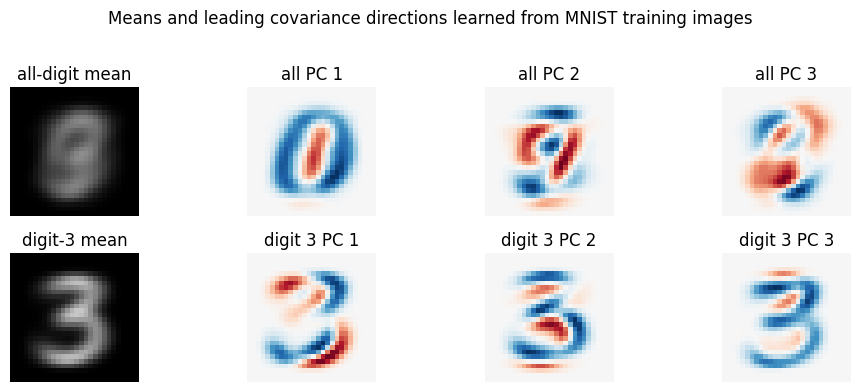

In [5]:
plot_pca_components(mnist_full_gaussian, mnist_class_gaussian)


In [6]:
balanced_indexes = torch.cat([
    torch.where(mnist_test_labels == digit)[0][:64]
    for digit in range(10)
])
balanced_clean = mnist_test_images[balanced_indexes]
set_seed(SEED + 332)
balanced_noisy = balanced_clean + MNIST_SIGMA * torch.randn_like(balanced_clean)
balanced_denoised = pca_posterior_mean(
    balanced_noisy, MNIST_SIGMA, mnist_full_gaussian,
)
display(pd.Series({
    "noisy MSE, all digits": float(torch.mean((balanced_noisy - balanced_clean).square())),
    "full-data PCA MSE, all digits": float(torch.mean((balanced_denoised - balanced_clean).square())),
}).round(4))


noisy MSE, all digits            0.2020
full-data PCA MSE, all digits    0.0202
dtype: float64

,method,held-out MSE,PSNR (dB)
0,noisy input,0.2028,6.9290
1,all-digit Gaussian,0.0207,16.8398
2,digit-3 Gaussian,0.0168,17.7513


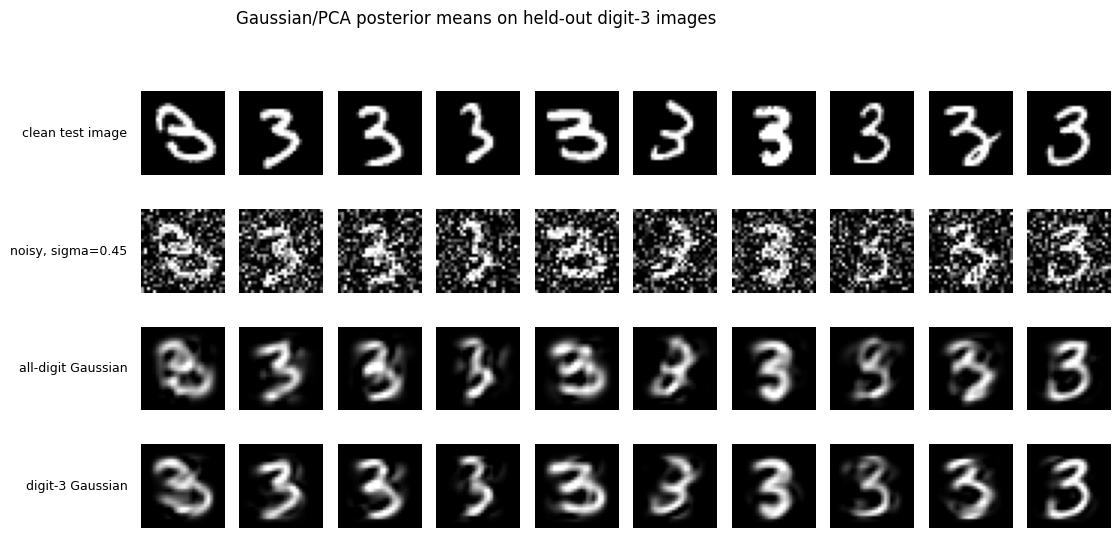

In [7]:
held_out_pool = torch.where(mnist_test_labels == MNIST_TARGET)[0]
held_out_indexes = held_out_pool[:256]
mnist_clean = mnist_test_images[held_out_indexes]
set_seed(SEED + 333)
mnist_noisy = mnist_clean + MNIST_SIGMA * torch.randn_like(mnist_clean)
mnist_full_denoised = pca_posterior_mean(mnist_noisy, MNIST_SIGMA, mnist_full_gaussian)
mnist_class_denoised = pca_posterior_mean(mnist_noisy, MNIST_SIGMA, mnist_class_gaussian)

def image_mse(images):
    return float(torch.mean((images - mnist_clean).square()).cpu())

mnist_mse = {
    "noisy input": image_mse(mnist_noisy),
    "all-digit Gaussian": image_mse(mnist_full_denoised),
    "digit-3 Gaussian": image_mse(mnist_class_denoised),
}
mnist_metrics = pd.DataFrame({
    "method": list(mnist_mse),
    "held-out MSE": list(mnist_mse.values()),
    "PSNR (dB)": [10 * np.log10(1.0 / value) for value in mnist_mse.values()],
})
display(mnist_metrics.round(4))

plot_image_rows([
    ("clean test image", mnist_clean),
    (f"noisy, sigma={MNIST_SIGMA}", mnist_noisy),
    ("all-digit Gaussian", mnist_full_denoised),
    ("digit-3 Gaussian", mnist_class_denoised),
], title="Gaussian/PCA posterior means on held-out digit-3 images")


The class-specific model usually removes more noise from typical 3s, but its
stronger prior can also suppress atypical details. The images make the trade-off
visible before we write it algebraically.

## 3. What rule produced those images?

Write the base point as $x_{noise}=s\epsilon$, with
$\epsilon\sim\mathcal{N}(0,I)$ and `s=1.8`. For `t>0`, divide the linear path by
`t`:

$$y=\frac{x_t}{t}=x_{data}+\sigma_{eff}\epsilon,\qquad
\sigma_{eff}=s\frac{1-t}{t}.$$

The flow state has become an ordinary additive-noise observation. Under a
Gaussian data model with mean $\mu$ and covariance $C$, its posterior mean is

$$D(y,\sigma)=\mu+C(C+\sigma^2I)^{-1}(y-\mu).$$

In a principal direction with variance $\lambda_i$, the observed coordinate is
multiplied by $\lambda_i/(\lambda_i+\sigma^2)$. High-variance structure is
retained more strongly; uncertain directions shrink more. The factor `s` is
required because the toy base distribution is not unit variance.


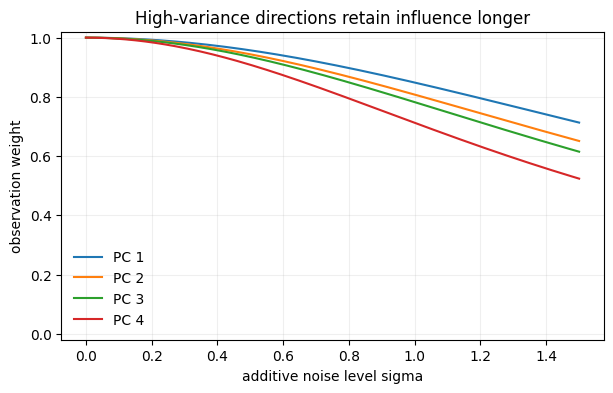

In [8]:
plot_pca_shrinkage(mnist_class_gaussian)


The curves show the rule without a matrix inverse: as noise increases, every
observation coordinate receives less weight, but high-variance principal
directions retain influence longer.

[Li, Dai, and Qu (NeurIPS 2024)](https://arxiv.org/abs/2410.24060) provide
broader evidence connecting diffusion denoisers with empirical Gaussian
denoisers in a generalization regime. Our MNIST panel is a small teaching test,
not a reproduction of that paper.

**Change one thing:** Set `MNIST_SIGMA` to `0.25` or `0.70` and rerun the MNIST
cells. Compare how much the observation and the class prior control the output.

## 4. How does denoising become a steering signal?

The image example shows what one Gaussian posterior mean preserves and loses.
For steering, we compare two such estimates at the same noisy state. Their
difference asks for structure favored by the target-class distribution relative
to the broad distribution. The gate below limits that correction to the
high-noise part of the trajectory. This literal subtraction is the mechanism
called **noise alignment** in the paper.

**Before you run:** Should the arrows point toward one common coordinate, or
change with the local state because two posterior means are being compared?


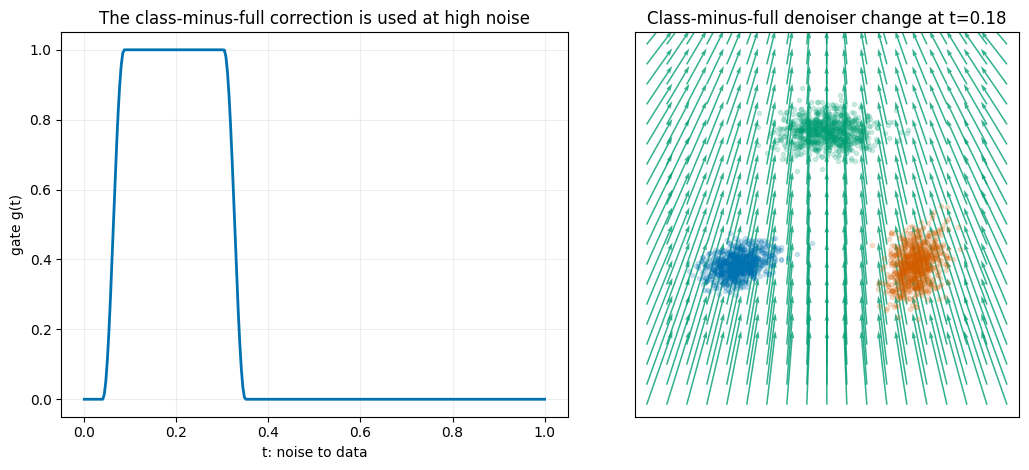

In [9]:
grid_1d = torch.linspace(-4.5, 4.5, 19, device=device)
gx, gy = torch.meshgrid(grid_1d, grid_1d, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)
t_value = 0.18
t = torch.full((grid.shape[0], 1), t_value, device=device)
y = grid / t
sigma = BASE_STD * (1 - t_value) / t_value

D_target = gaussian_posterior_mean(
    y, sigma, steering_stats.means[TARGET_CLASS], steering_stats.covariances[TARGET_CLASS]
)
D_full = gaussian_posterior_mean(
    y, sigma, steering_stats.full_mean, steering_stats.full_covariance
)
denoiser_delta = D_target - D_full

plot_class_minus_full_field(
    grid, denoiser_delta, steering_data, steering_labels,
    target_class=TARGET_CLASS, t_value=t_value, start=0.04, end=0.35,
)


## 5. Does the correction improve paired samples?

All methods below use the same initial noise, Heun solver, step count, and target
reference. The only change is the class-minus-full correction strength. The
correction is active for `t in [0.04, 0.35]`, the high-noise part of our
noise-to-data path.

**Before you run:** Increasing strength should move more samples toward the
target class. Must target fit and diversity improve monotonically as well?


In [10]:
def class_minus_full_velocity(strength):
    def velocity(t, x):
        with torch.no_grad():
            base = model(t, x)
            t_column = t[:, None].clamp_min(0.04)
            y = x / t_column
            sigma = BASE_STD * (1 - t) / t.clamp_min(0.04)
            target_estimate = gaussian_posterior_mean(
                y, sigma, steering_stats.means[TARGET_CLASS],
                steering_stats.covariances[TARGET_CLASS],
            )
            full_estimate = gaussian_posterior_mean(
                y, sigma, steering_stats.full_mean, steering_stats.full_covariance,
            )
            gate = window_gate(t, 0.04, 0.35)[:, None]
            remaining = (1 - t_column).clamp_min(0.04)
            return base + strength * gate * (target_estimate - full_estimate) / remaining
    return velocity


In [11]:
set_seed(SEED + 30)
x0 = sample_base(1800, device=device)
CORRECTION_STRENGTH = 1.6
strengths = [0.0, 0.8, CORRECTION_STRENGTH]
methods = {"baseline": base_velocity(model)}
methods.update({
    f"class-minus-full {s:.1f}": class_minus_full_velocity(s)
    for s in strengths
})

rows, paths = compare_steering_methods(
    methods, x0, target_reference, evaluation_stats,
    target_class=TARGET_CLASS, steps=64,
)
correction_table = pd.DataFrame(rows)
correction_table["strength"] = [
    np.nan if name == "baseline" else float(name.rsplit(" ", 1)[-1])
    for name in correction_table["method"]
]


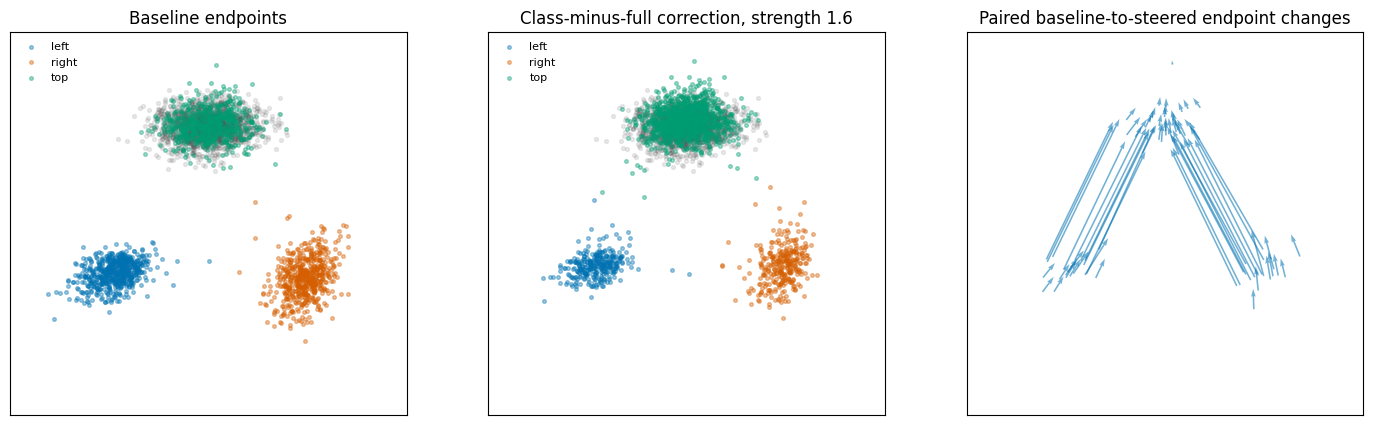

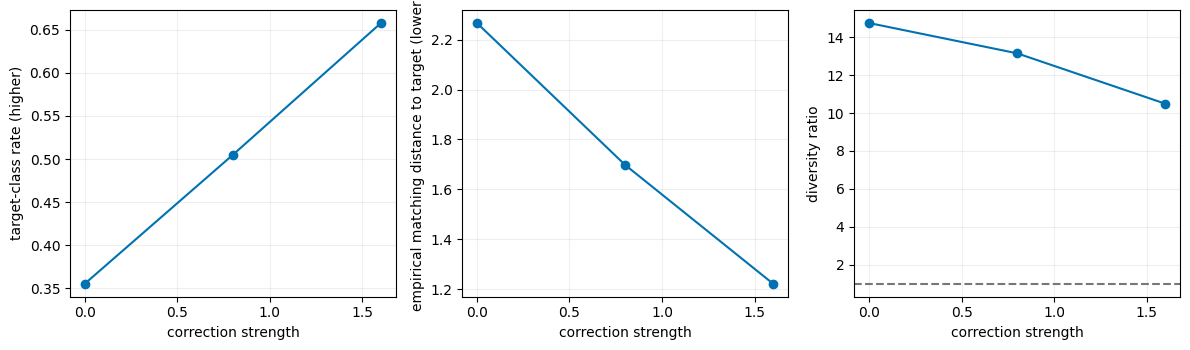

In [12]:
plot_class_minus_full_comparison(
    paths, correction_table, target_reference, evaluation_stats,
    strength=CORRECTION_STRENGTH,
)


In [13]:
selected = correction_table.set_index("method").loc[
    ["baseline", f"class-minus-full {CORRECTION_STRENGTH:.1f}"],
    ["target_rate", "target_wasserstein", "mean_error", "diversity_ratio"],
]
display(selected.rename(columns={
    "target_rate": "target-class rate",
    "target_wasserstein": "empirical matching distance",
    "mean_error": "target mean error",
    "diversity_ratio": "diversity ratio",
}).round(4))


,target-class rate,empirical matching distance,target mean error,diversity ratio
method,,,,
baseline,0.3556,2.2670,2.1689,14.7456
class-minus-full 1.6,0.6578,1.2215,0.9966,10.4933


## Reading the paired result

Read the endpoints and metrics together. A higher target-class rate indicates
stronger control, a lower empirical matching distance indicates better
agreement with target examples, and the diversity ratio shows whether that
gain came from collapse or excessive spread. The diversity ratio is the total
coordinate variance of the generated batch divided by that of target-class
examples: `1` matches their overall scale, values below `1` are too narrow, and
large values remain too broad. The model remains unconditional and unchanged;
only the target-class and full-data statistics are fitted offline.

The useful signal is coarse because one mean and covariance cannot represent
every detail of a multimodal distribution. In this toy setting it produces
partial steering, not a full class-conditional generator. Notebook `04` asks
what changes when a state-dependent objective gradient replaces those fixed
summary statistics.
